# Fourier Series Coefficient Calculation

This notebook shows how to compute the Fourier Series coefficients $( b_n $) for periodic waveforms:
- Square Wave
- Triangle Wave
- Sawtooth Wave

Each is derived step-by-step using symbolic integration with SymPy.


In [1]:
!pip install sympy

In [2]:
import sympy as sp

t, T, n = sp.symbols('t T n', real=True, positive=True)
w0 = 2 * sp.pi / T


## General Fourier Series Form

A periodic signal $x(t)$ with period $T$ can be expressed using a Fourier series as:

$$
x(t) = a_0 + \sum_{n=1}^{\infty} \left[ a_n \cos(2\pi n f_0 t) + b_n \sin(2\pi n f_0 t) \right]
$$

We compute only the sine coefficients $b_n$ because squre wave is a odd function:

$$
b_n = \frac{2}{T} \int_0^T x(t) \sin(2 \pi n f_0 t) \, dt
$$


## Square Wave

In [3]:
# Square wave
expr1 = 1
expr2 = -1
sin_term = sp.sin(n * w0 * t)

int1 = sp.integrate(expr1 * sin_term.subs(w0, 2 * sp.pi), (t, 0, 0.5))
int2 = sp.integrate(expr2 * sin_term.subs(w0, 2 * sp.pi), (t, 0.5, 1))
bn_square = (2 / 1) * (int1 + int2)
bn_square.simplify()

(-2.0*cos(pi*n) + 1.0*cos(2*pi*n) + 1.0)/(pi*n)

So  
When n is odd, $( b_n $) = $ 4/(\pi.n) $  
When n is even, $( b_n $) = $ 0 $

## Triangle Wave

The triangle wave is piecewise linear:
- Increasing slope in [0, T/2)
- Decreasing slope in [T/2, T)

We compute its Fourier sine coefficients \$( b_n $\) using symbolic integration.


In [4]:
# Triangle wave
expr1 = 4 * t
expr2 = -4 * t + 4
sin_term = sp.sin(n * 2 * sp.pi * t)

int1 = sp.integrate(expr1 * sin_term, (t, 0, 0.5))
int2 = sp.integrate(expr2 * sin_term, (t, 0.5, 1))
bn_triangle = 2*(int1 + int2)
bn_triangle.simplify()


2*(2*sin(pi*n) - sin(2*pi*n))/(pi**2*n**2)

Use of the sympy library is not useful in this content because of the sympy library simplification so I use the mathemetical formula in there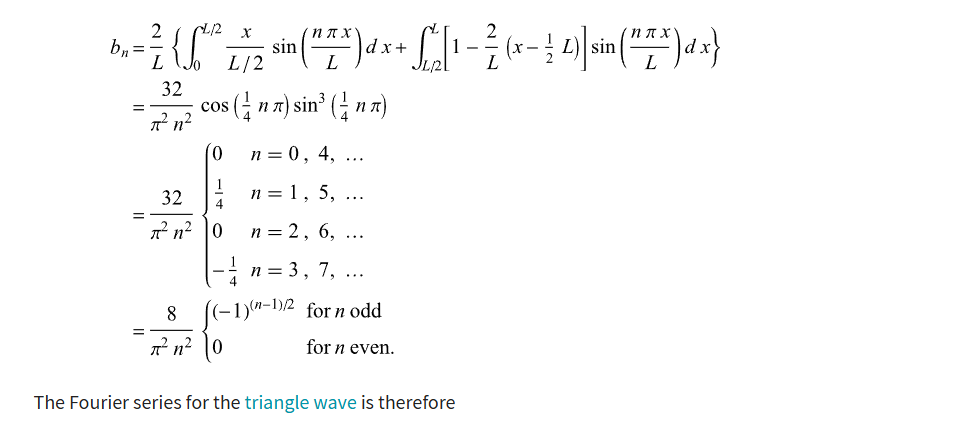

When n is odd, $( b_n $) = $ 8.(-1)^{(n-1)/2}/(\pi^2.n^2) $  
When n is even, $( b_n $) = $ 0 $

## Sawtooth Wave

The sawtooth wave increases linearly from -1 to 1 over one period.

We compute its Fourier sine coefficients \($ b_n $\).


In [5]:
# Sawtooth wave
expr = 2 * t - 1
sin_term = sp.sin(n * 2 * sp.pi * t)

int_saw = sp.integrate(expr * sin_term, (t, 0, 1))
bn_saw = int_saw
bn_saw.simplify()


(-pi*n*cos(pi*n)**2 + sin(2*pi*n)/2)/(pi**2*n**2)

 $( b_n $) = $ -1/(\pi.n) $  

## NOTE  
In my .grc file, I added 8 harmonics for the sawtooth wave. Square and triangle waves contain only odd harmonics, but the sawtooth wave includes both even and odd harmonics. So, I added the 2nd, 4th, 6th, and 8th harmonic frequencies to represent the sawtooth wave more clearly.